# Importing Libreries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pmdarima import auto_arima

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [3]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [4]:
# Set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
plt.style.use('fivethirtyeight')

# Loading Data

In [5]:
# Behaviour datasets configuration
dataset_1 = "Mask Wearing.csv"
target_1 = "mask_wearing"

dataset_2 = "Hand Washing.csv"
target_2 = "wash_hands"

dataset_3 = "Avoid Crowded Areas.csv"
target_3 = "avoid_crowded_areas"

dataset_4 = "Self Isolation.csv"
target_4 = "willingness_self_isolate"

In [6]:
# Load and prepare daily time series data with exogenous variables
def load_and_prepare_data(dataset, target):
    """
    Loads the final behaviour dataset and converts it into a daily
    time-series dataset for SARIMAX modelling.

    Since the original dataset contains multiple survey responses per date,
    the data is aggregated by date using mean. The target series and
    exogenous variables are prepared in the same structure used in the
    time-series notebook with exogenous variables.
    """

    df = pd.read_csv(dataset)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values("date")

    exog_vars = [
        # Common perception and behavioural predictors
        "covid_dangerous_for_me",
        "likely_to_get_covid",
        "trust_in_government_handling",
        "important_to_improve_health",
        "life_affected_by_covid",

        # Policy variables
        "mask_policy",
        "gathering_restriction",
        "cancel_public_events",
        "stay_home_requirement",
        "public_information_campaign",
        "testing_policy",
        "contact_tracing",
        "stringency_index",

        # Epidemiological variables
        "new_cases_smoothed",
        "new_deaths_smoothed",
        "reproduction_rate",
        "hospital_patients",
        "people_fully_vaccinated_per_hundred",

        # Date features
        "year",
        "month",
        "days_since_start",
        "week_index",

        # Lag features
        "new_cases_smoothed_lag7",
        "new_cases_smoothed_lag14",
        "new_deaths_smoothed_lag7",
        "new_deaths_smoothed_lag14",
        "reproduction_rate_lag7",
        "reproduction_rate_lag14",
        "hospital_patients_lag7",
        "hospital_patients_lag14",
        "people_fully_vaccinated_per_hundred_lag7",
        "people_fully_vaccinated_per_hundred_lag14",
        "stringency_index_lag7",
        "stringency_index_lag14",
        "mask_policy_lag7",
        "mask_policy_lag14",
        "stay_home_requirement_lag7",
        "stay_home_requirement_lag14",
        "gathering_restriction_lag7",
        "gathering_restriction_lag14",
        "cancel_public_events_lag7",
        "cancel_public_events_lag14",

        # Interaction features
        "policy_x_cases",
        "risk_x_trust"
    ]

    # Keep only variables that exist in the selected dataset
    exog_vars = [
        col for col in exog_vars
        if col in df.columns
    ]

    # Aggregate individual-level survey data into daily time-series data
    daily_df = (
        df.groupby("date")[[target] + exog_vars]
        .mean()
        .reset_index()
    )

    # Set date as index
    daily_df = daily_df.set_index("date")

    # Ensure daily frequency
    daily_df = daily_df.asfreq("D")

    # Fill missing values after daily indexing
    daily_df = daily_df.ffill().bfill()

    # Separate target and exogenous variables, similar to y_merge and X_merge
    y_merge = daily_df[target]
    X_merge = daily_df[exog_vars]

    print("Dataset loaded successfully")
    print("Daily dataset shape:", daily_df.shape)
    print("Target variable:", target)
    print("Target shape:", y_merge.shape)
    print("Exogenous variable shape:", X_merge.shape)
    print("Number of exogenous variables:", len(exog_vars))

    return daily_df, y_merge, X_merge, exog_vars

# SARIMA Model

In [7]:
# Check Stationarity
def check_stationarity(series):
    """
    Performs Augmented Dickey-Fuller test on the target series.
    """

    result = adfuller(series.dropna())

    print("\nStationarity Check")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Result: Series is stationary")
    else:
        print("Result: Series is not stationary")

    return result[1]

In [8]:
# Train-test split
def split_data(daily_df, y_merge, X_merge, train_ratio=0.80):
    """
    Splits the target and exogenous variables chronologically.
    Exogenous variables are not scaled here to keep the SARIMAX approach
    consistent with the time-series notebook with exogenous variables.
    """

    train_size = int(len(daily_df) * train_ratio)

    y_train = y_merge.iloc[:train_size]
    y_test = y_merge.iloc[train_size:]

    X_train = X_merge.iloc[:train_size]
    X_test = X_merge.iloc[train_size:]

    print("Train-Test Period")
    print("Training target shape:", y_train.shape)
    print("Testing target shape:", y_test.shape)
    print("Training exogenous shape:", X_train.shape)
    print("Testing exogenous shape:", X_test.shape)
    print("Full target shape:", y_merge.shape)
    print("Full exogenous shape:", X_merge.shape)

    return y_train, y_test, X_train, X_test

In [9]:
# Find best SARIMA order using auto-ARIMA
def find_best_sarimax_order(y_train, X_train):
    """
    Uses auto_arima to find suitable SARIMAX order and seasonal order.
    Weekly seasonality is used because the data is daily.
    """

    auto_model = auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=7,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        max_d=2,
        start_P=0,
        start_Q=0,
        max_P=2,
        max_Q=2,
        max_D=1,
        trace=True,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore"
    )

    order = auto_model.order
    seasonal_order = auto_model.seasonal_order

    print("\nBest SARIMAX Parameters")
    print("Order:", order)
    print("Seasonal Order:", seasonal_order)

    return order, seasonal_order

In [10]:
# Train SARIMAX model with exogenous variables
def train_sarimax_model(y_merge, X_merge, order, seasonal_order):
    """
    Fits SARIMAX on the full observed time series with exogenous predictors.
    This follows the same style as the time-series notebook with exogenous
    variables, where SARIMAX is fitted using y_merge and X_merge.
    """

    mod = sm.tsa.statespace.SARIMAX(
        y_merge,
        exog=X_merge,
        order=order,
        seasonal_order=seasonal_order,
        enforce_invertibility=False
    )

    results = mod.fit(disp=False)

    print("SARIMAX Model Summary")
    print(results.summary())

    return results

In [11]:
# Predict using SARIMAX model
def predict_sarimax(model_result, y_test):
    """
    Creates one-step-ahead predictions for the observed test period.

    This follows the time-series notebook approach:
    pred = results.get_prediction(start=test_start_date, dynamic=False)

    This is not future forecasting. It predicts values for dates already
    present in the test period.
    """

    test_start_date = y_test.index[0]
    test_end_date = y_test.index[-1]

    pred = model_result.get_prediction(
        start=test_start_date,
        end=test_end_date,
        dynamic=False
    )

    predictions = pred.predicted_mean

    predictions = pd.Series(
        predictions,
        index=y_test.index
    )

    return predictions


In [12]:
# Evaluate model
def evaluate_model(y_test, predictions):
    """
    Calculates model accuracy using common regression metrics.
    R-squared is not included because it is not required for this analysis.
    """

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    results = pd.DataFrame({
        "Model": ["SARIMAX"],
        "MSE": [mse],
        "RMSE": [rmse],
        "MAE": [mae],
        "MAPE": [mape]
    })

    print("SARIMAX Accuracy Results")
    print(results)

    return results

In [13]:
# Plot results
def plot_results(y_train, y_test, predictions, target):
    """
    Plots the complete training series, actual test data,
    one-step-ahead predicted values, actual vs predicted plot,
    and residual plot with clear colours.
    """

    # Convert target variable name into readable plot label
    target_labels = {
        "mask_wearing": "Mask Wearing",
        "wash_hands": "Hand Washing",
        "avoid_crowded_areas": "Avoid Crowded Areas",
        "willingness_self_isolate": "Self Isolation"
    }

    target_label = target_labels.get(
        target,
        target.replace("_", " ").title()
    )

    # Full time-series plot: training, actual test and prediction
    plt.figure(figsize=(16, 7))

    plt.plot(
        y_train.index,
        y_train,
        label="Training Data",
        color="#1f77b4",
        linewidth=2
    )

    plt.plot(
        y_test.index,
        y_test,
        label="Actual Test Data",
        color="#ff7f0e",
        linewidth=2.5
    )

    plt.plot(
        predictions.index,
        predictions,
        label="One-step ahead prediction",
        color="#d62728",
        linewidth=2.5,
    )

    plt.xlabel("Date", fontsize=16)
    plt.ylabel(target_label, fontsize=16)

    plt.legend(fontsize=12, loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Actual vs predicted values
    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        predictions,
        color="#1f77b4",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect prediction line"
    )

    plt.xlabel("Actual Values", fontsize=14)
    plt.ylabel("Predicted Values", fontsize=14)

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Residual plot
    residuals = y_test - predictions

    plt.figure(figsize=(14, 5))

    plt.plot(
        residuals.index,
        residuals,
        color="#1f77b4",
        linewidth=2
    )

    plt.axhline(
        y=0,
        color="red",
        linestyle="--",
        linewidth=2
    )
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Residuals", fontsize=14)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [14]:
# SARIMAX pipeline
def run_sarimax_pipeline(dataset, target):
    """
    Runs the full SARIMAX modelling pipeline with exogenous variables.
    """

    daily_df, y_merge, X_merge, exog_vars = load_and_prepare_data(
        dataset,
        target
    )

    check_stationarity(
        y_merge
    )

    y_train, y_test, X_train, X_test = split_data(
        daily_df,
        y_merge,
        X_merge
    )

    order, seasonal_order = find_best_sarimax_order(
        y_train,
        X_train
    )

    model_result = train_sarimax_model(
        y_merge,
        X_merge,
        order,
        seasonal_order
    )

    predictions = predict_sarimax(
        model_result,
        y_test
    )

    accuracy_results = evaluate_model(
        y_test,
        predictions
    )

    plot_results(
        y_train,
        y_test,
        predictions,
        target
    )

    return model_result, accuracy_results

# Results

Dataset loaded successfully
Daily dataset shape: (727, 45)
Target variable: mask_wearing
Target shape: (727,)
Exogenous variable shape: (727, 44)
Number of exogenous variables: 44

Stationarity Check
ADF Statistic: -4.8572007360904905
p-value: 4.2219253269175804e-05
Result: Series is stationary
Train-Test Period
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 44)
Testing exogenous shape: (146, 44)
Full target shape: (727,)
Full exogenous shape: (727, 44)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=4257.885, Time=0.93 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[7] inter

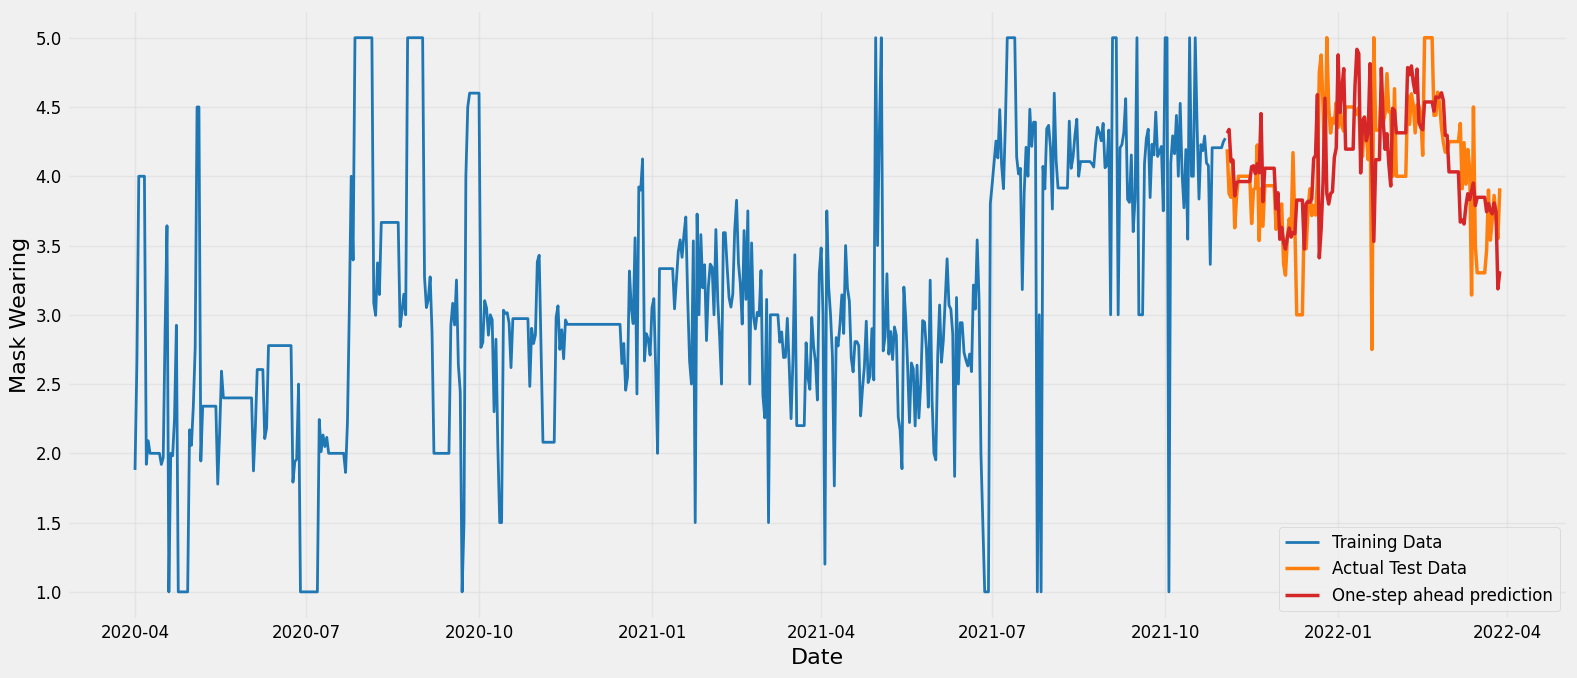

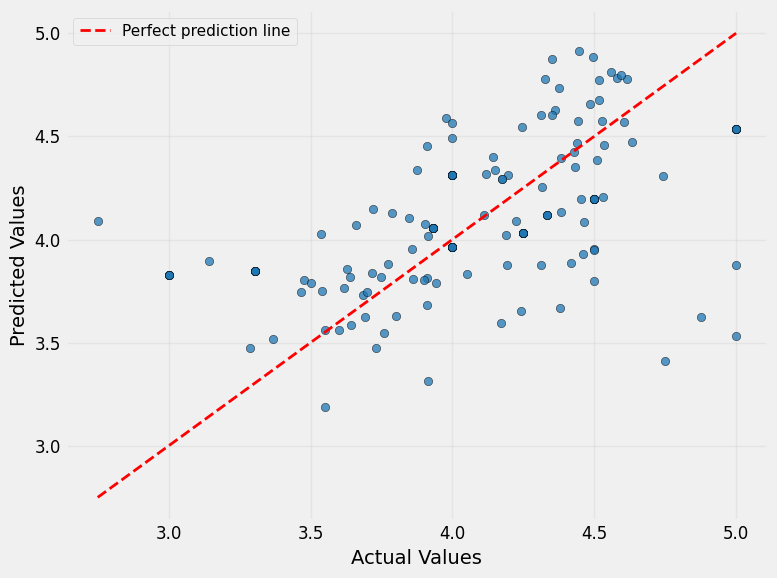

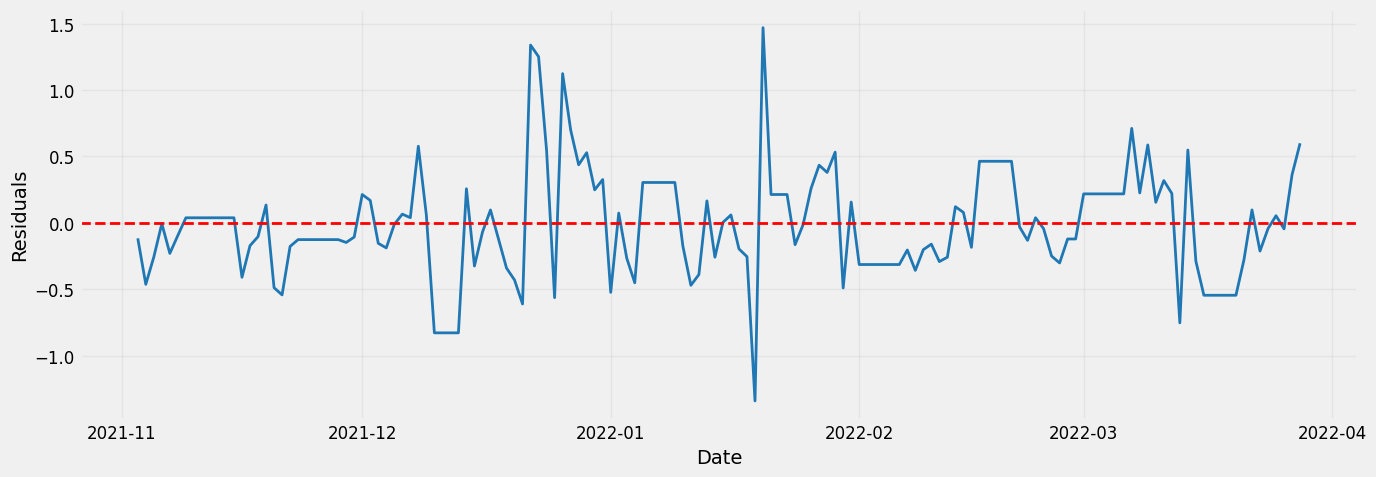

In [15]:
# Run model for mask wearing
mask_model, mask_accuracy = run_sarimax_pipeline(
    dataset_1,
    target_1
)

Dataset loaded successfully
Daily dataset shape: (715, 45)
Target variable: wash_hands
Target shape: (715,)
Exogenous variable shape: (715, 44)
Number of exogenous variables: 44

Stationarity Check
ADF Statistic: -9.293927448932413
p-value: 1.1597651425243651e-15
Result: Series is stationary
Train-Test Period
Training target shape: (572,)
Testing target shape: (143,)
Training exogenous shape: (572, 44)
Testing exogenous shape: (143, 44)
Full target shape: (715,)
Full exogenous shape: (715, 44)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=3365.246, Time=0.92 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[7] intercep

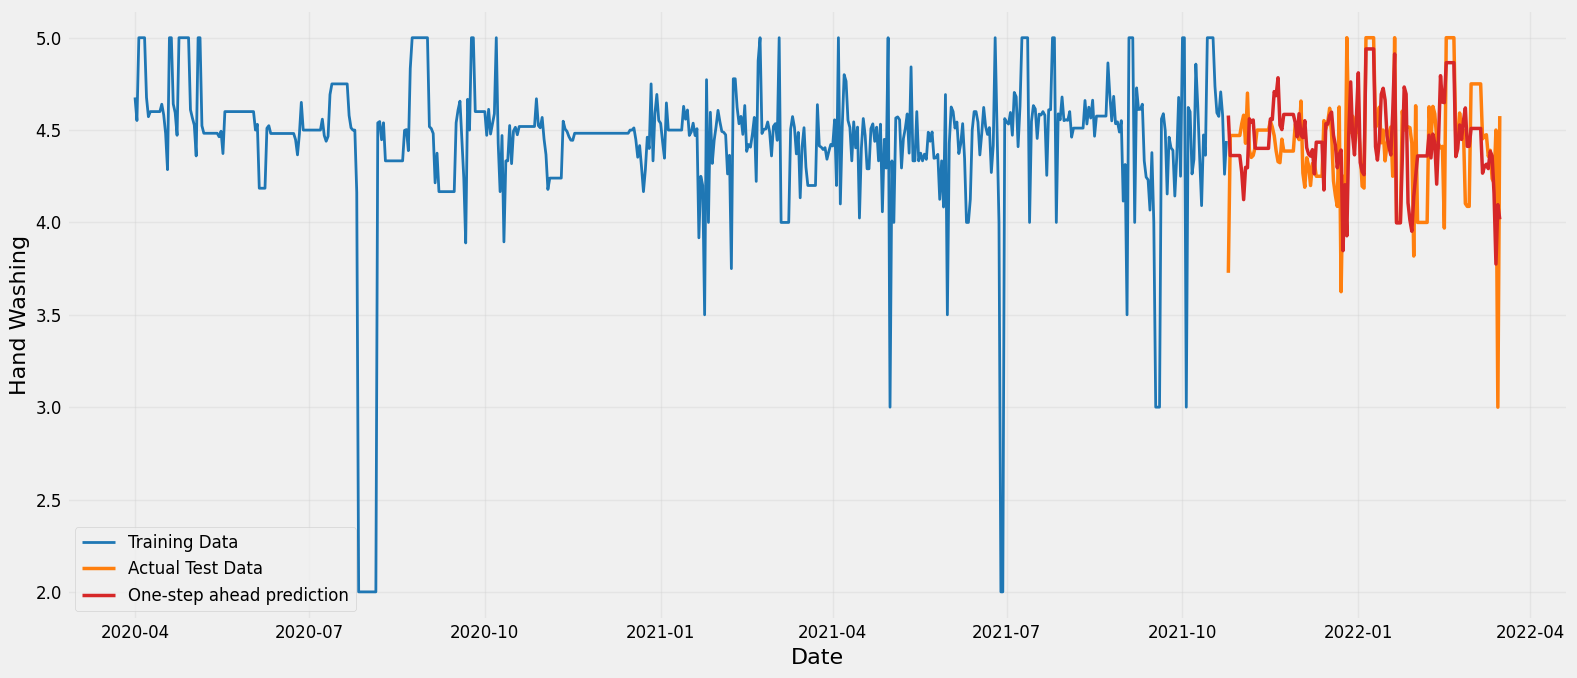

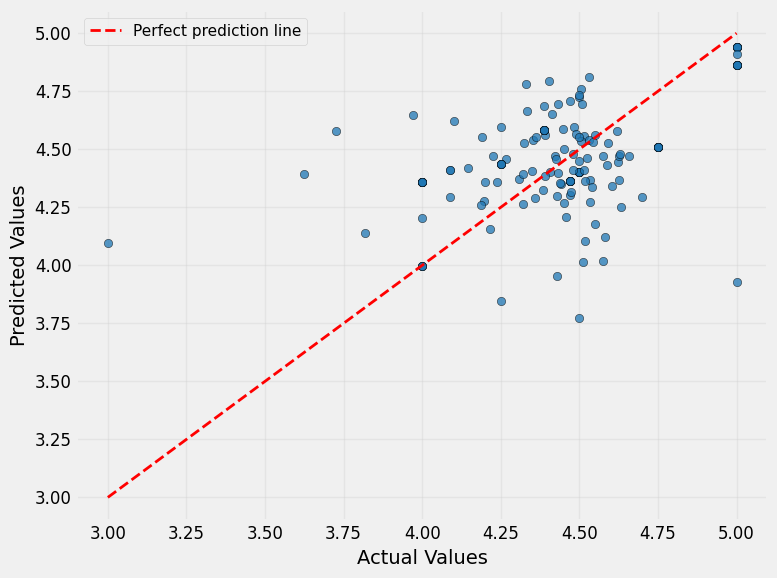

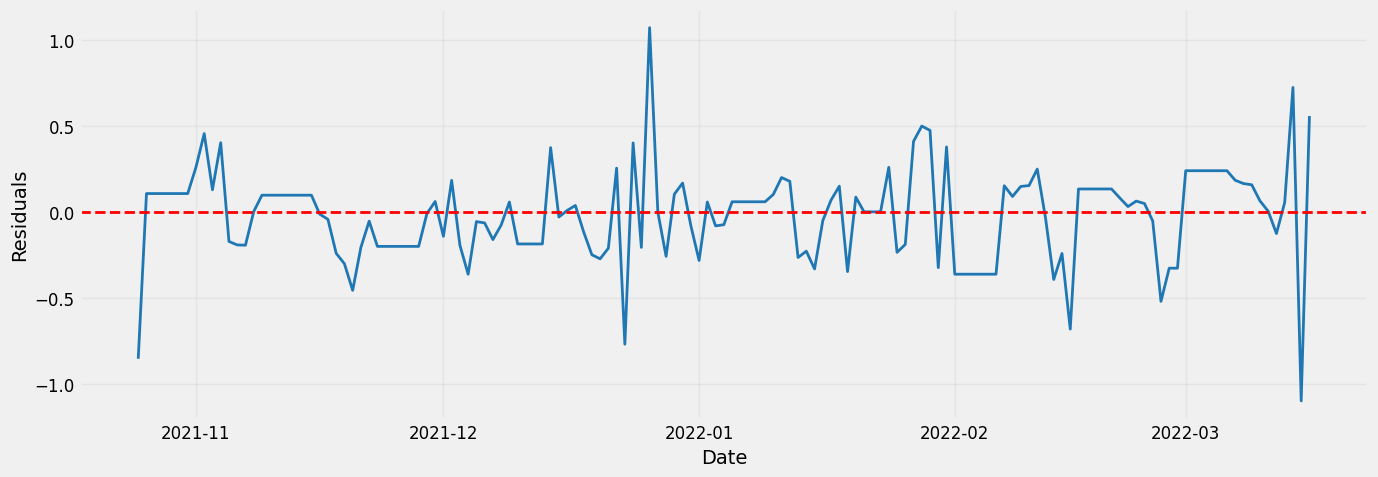

In [16]:
# Run model for hand washing
handwashing_model, handwashing_accuracy = run_sarimax_pipeline(
    dataset_2,
    target_2
)

Dataset loaded successfully
Daily dataset shape: (727, 45)
Target variable: avoid_crowded_areas
Target shape: (727,)
Exogenous variable shape: (727, 44)
Number of exogenous variables: 44

Stationarity Check
ADF Statistic: -7.2020615606250455
p-value: 2.351458071674493e-10
Result: Series is stationary
Train-Test Period
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 44)
Testing exogenous shape: (146, 44)
Full target shape: (727,)
Full exogenous shape: (727, 44)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=3926.700, Time=1.05 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,0)[7]

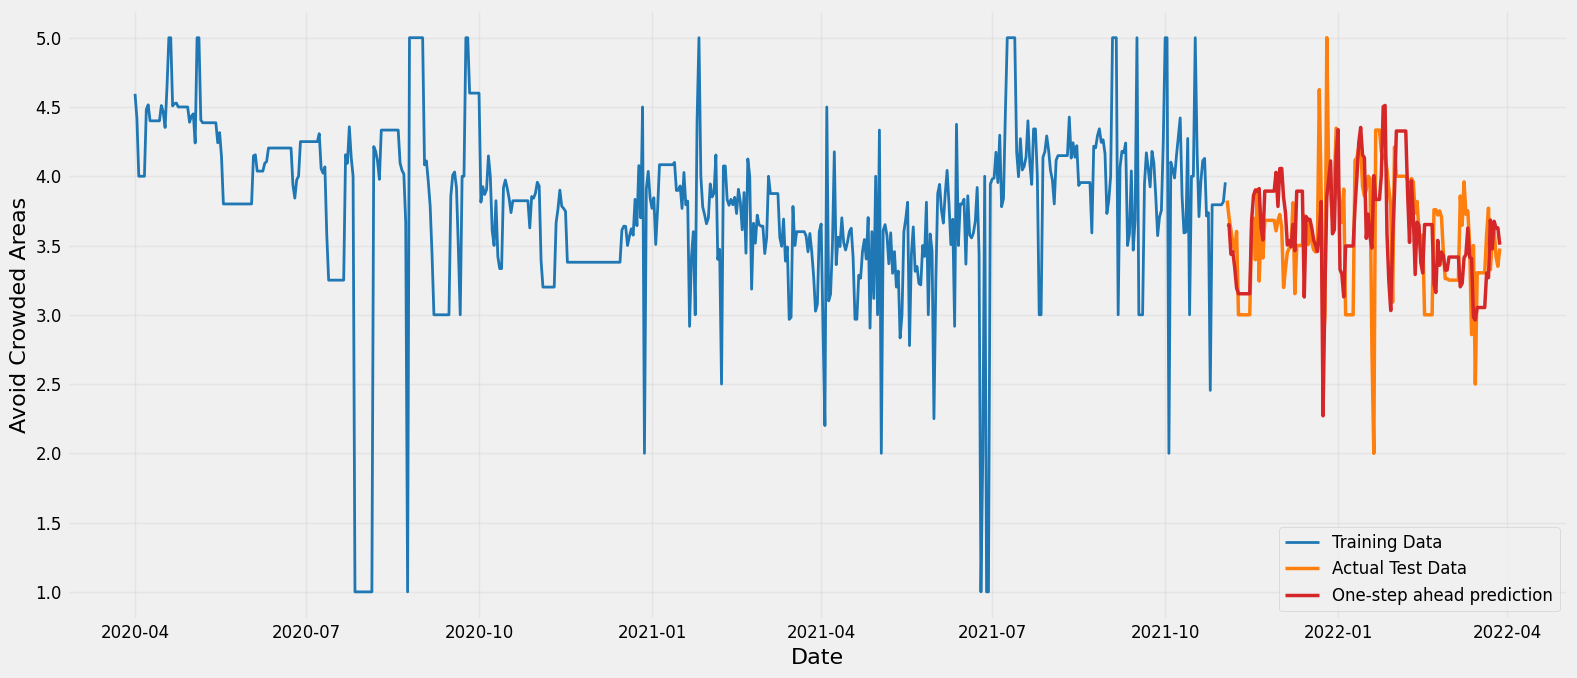

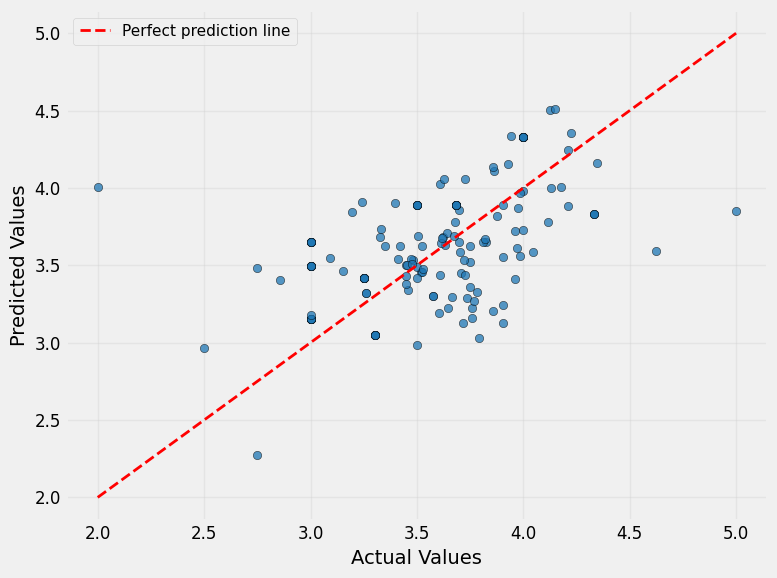

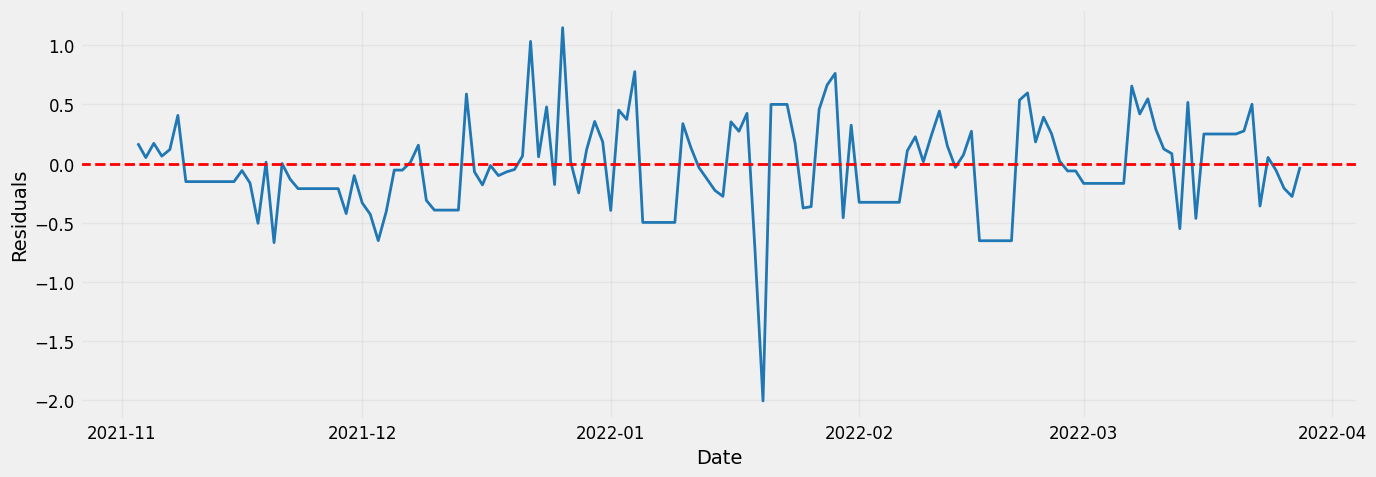

In [17]:
# Run model for avoid crowded areas
crowded_model, crowded_accuracy = run_sarimax_pipeline(
    dataset_3,
    target_3
)

Dataset loaded successfully
Daily dataset shape: (727, 45)
Target variable: willingness_self_isolate
Target shape: (727,)
Exogenous variable shape: (727, 44)
Number of exogenous variables: 44

Stationarity Check
ADF Statistic: -6.449163603615237
p-value: 1.5388218162257924e-08
Result: Series is stationary
Train-Test Period
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 44)
Testing exogenous shape: (146, 44)
Full target shape: (727,)
Full exogenous shape: (727, 44)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=3684.041, Time=0.92 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,0)(0,0,

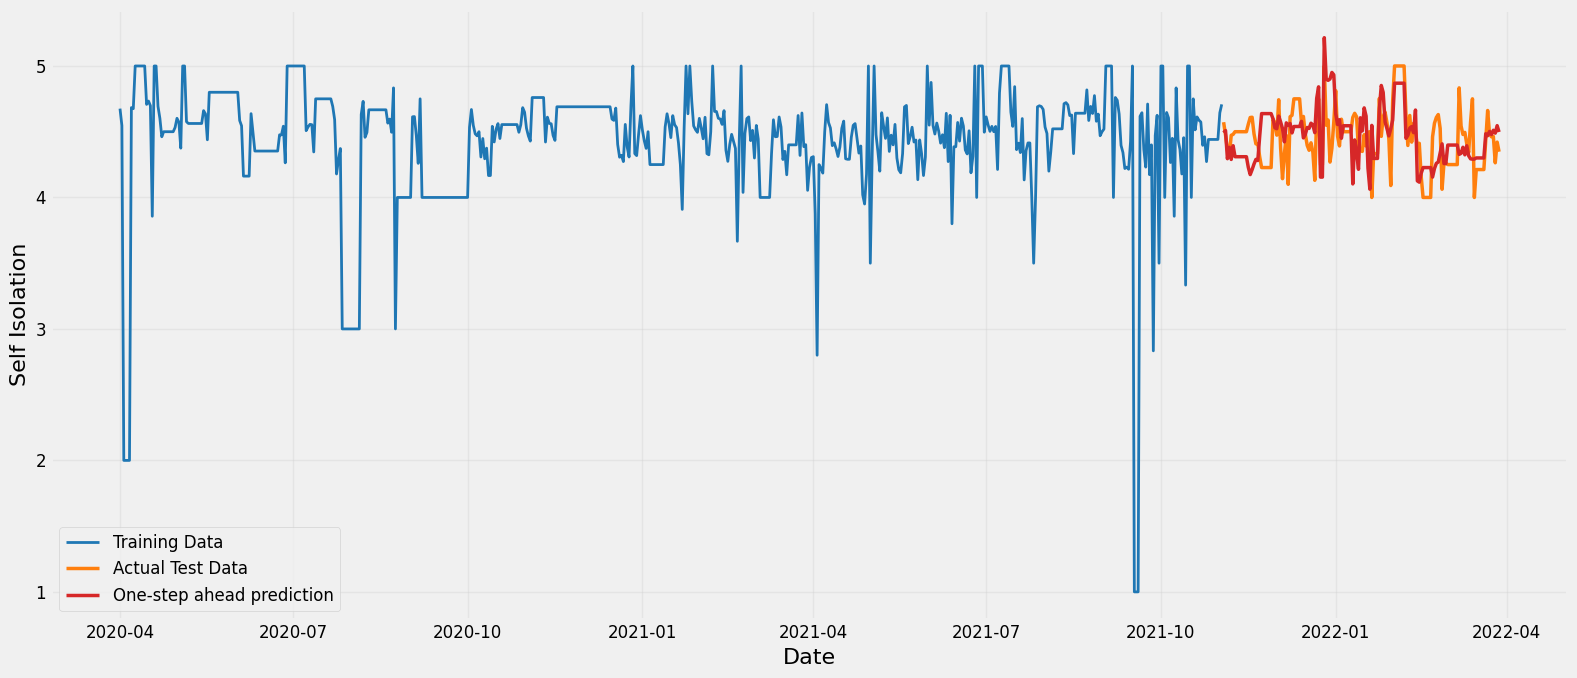

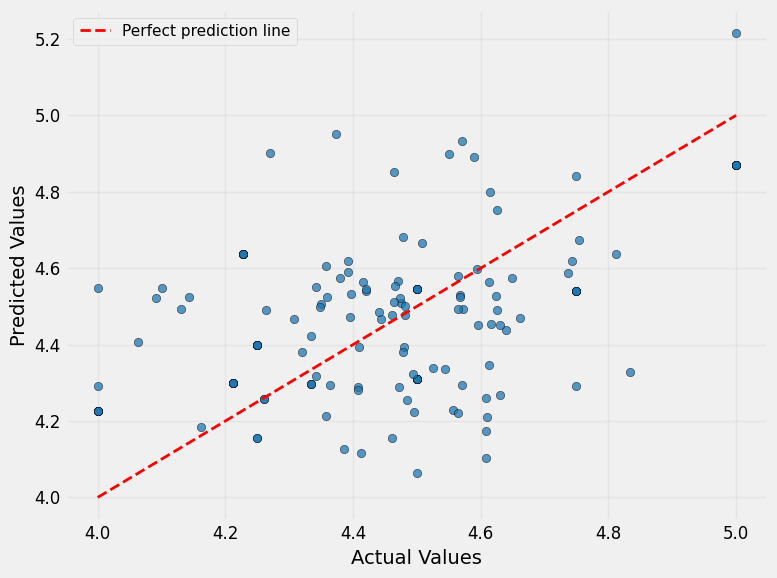

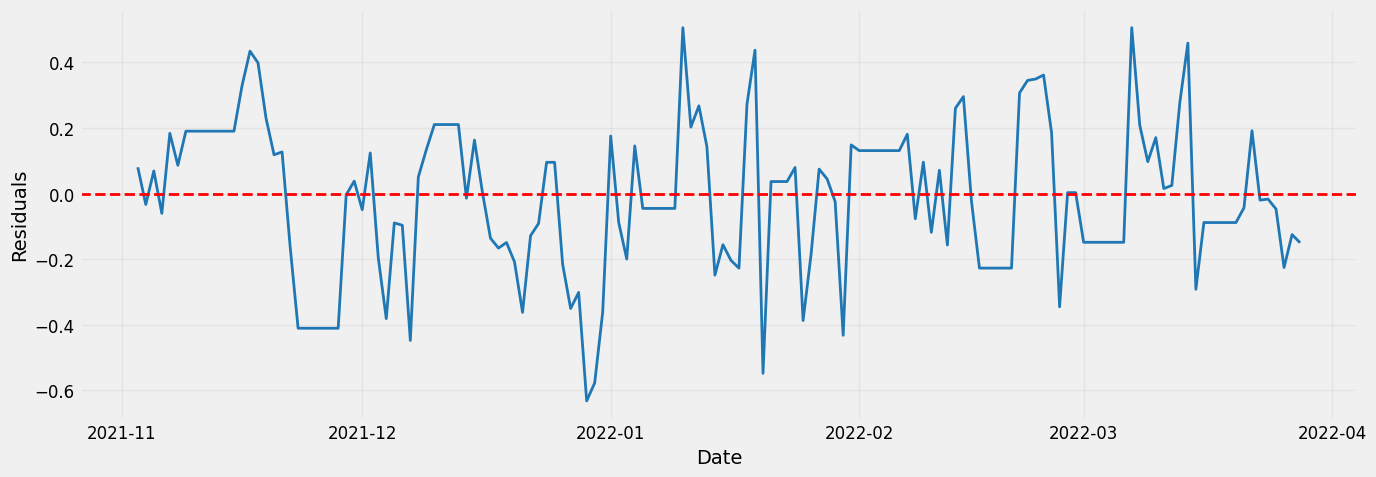

In [18]:
# Run model for self isolation
self_model, self_accuracy = run_sarimax_pipeline(
    dataset_4,
    target_4
)

In [19]:
# Combine VAR results for all 4 outcomes
sarima_results_table = pd.concat(
    [
        mask_accuracy,
        handwashing_accuracy,
        crowded_accuracy,
        self_accuracy
    ],
    ignore_index=True
)

sarima_results_table.insert(
    0,
    "Outcome Variable",
    [
        "Mask Wearing",
        "Hand Washing",
        "Avoid Crowded Areas",
        "Self Isolation"
    ]
)

sarima_results_table

,Outcome Variable,Model,MSE,RMSE,MAE,MAPE
0,Mask Wearing,SARIMAX,0.172400,0.415211,0.314364,0.078920
1,Hand Washing,SARIMAX,0.078479,0.280142,0.208322,0.048552
2,Avoid Crowded Areas,SARIMAX,0.161756,0.402189,0.310479,0.090700
3,Self Isolation,SARIMAX,0.053642,0.231607,0.187899,0.042514
